# KENYA TOP 100 PREDICTION

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv(r'C:\Users\ChristineKakina\PycharmProjects\HitSongPredictor\Kenya.csv')
df = data.copy()


In [55]:
df.head()

,artist,album,track_name,track_id,danceability,energy,key,loudness,mode,speechiness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,Nyashinski,Hello,Hello,5oHGYyIokNKyDvyi4pNu44,0.633,0.695,8,-6.048,1,0.166,0.000000,0.0783,0.605,126.521,230000,5
1,Nyashinski,Properly (feat. Femi One),Properly (feat. Femi One),6zSFJHyjfajlXTSV7p4j0G,0.909,0.560,9,-7.345,1,0.366,0.000000,0.0295,0.704,110.137,196364,4
2,Nyashinski,Hapo Tu (feat. Chris Kaiga),Hapo Tu (feat. Chris Kaiga),6JR3F5nXtkkHwiCHIeYqSC,0.726,0.706,1,-3.448,1,0.343,0.000587,0.0291,0.555,119.896,187556,3
3,Nyashinski,Mungu Pekee,Mungu Pekee,1QgM3SejXDyHkqt0guA4TX,0.718,0.759,0,-4.548,1,0.173,0.000000,0.0624,0.769,100.008,230452,4
4,Nyashinski,Bebi Bebi,Bebi Bebi,4U2PpIPmXV04EyrzNe0Ary,0.708,0.442,1,-8.699,1,0.166,0.000000,0.0456,0.788,146.010,240000,4


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   artist            53 non-null     object 
 1   album             53 non-null     object 
 2   track_name        53 non-null     object 
 3   track_id          53 non-null     object 
 4   danceability      53 non-null     float64
 5   energy            53 non-null     float64
 6   key               53 non-null     int64  
 7   loudness          53 non-null     float64
 8   mode              53 non-null     int64  
 9   speechiness       53 non-null     float64
 10  instrumentalness  53 non-null     float64
 11  liveness          53 non-null     float64
 12  valence           53 non-null     float64
 13  tempo             53 non-null     float64
 14  duration_ms       53 non-null     int64  
 15  time_signature    53 non-null     int64  
dtypes: float64(8), int64(4), object(4)
memory usag

In [57]:
df.describe()

,danceability,energy,key,loudness,mode,speechiness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
count,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000
mean,0.700981,0.684472,5.584906,-6.981038,0.641509,0.184936,0.002764,0.146174,0.615925,123.243868,231153.867925,3.981132
std,0.131371,0.119826,3.477587,2.078627,0.484146,0.127412,0.014791,0.117756,0.162706,34.149882,70110.430041,0.366405
min,0.351000,0.442000,0.000000,-11.587000,0.000000,0.032800,0.000000,0.029100,0.279000,77.448000,139227.000000,3.000000
25%,0.628000,0.585000,2.000000,-8.199000,0.000000,0.081400,0.000000,0.094000,0.527000,96.980000,193358.000000,4.000000
50%,0.706000,0.687000,6.000000,-6.740000,1.000000,0.171000,0.000000,0.112000,0.615000,101.997000,223403.000000,4.000000
75%,0.792000,0.773000,9.000000,-5.562000,1.000000,0.254000,0.000104,0.155000,0.750000,149.979000,247980.000000,4.000000
max,0.928000,0.965000,11.000000,-3.313000,1.000000,0.510000,0.107000,0.657000,0.929000,187.936000,598074.000000,5.000000


In [58]:
# Select numeric columns
numeric_cols = df.select_dtypes(include='number').columns.tolist()

# Drop columns that make little or no difference to a song
drop_cols = ['duration_ms', 'tempo', 'key', 'time_signature','loudness','mode']
relevant_features = [col for col in numeric_cols if col not in drop_cols]

df[relevant_features].info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   danceability      53 non-null     float64
 1   energy            53 non-null     float64
 2   speechiness       53 non-null     float64
 3   instrumentalness  53 non-null     float64
 4   liveness          53 non-null     float64
 5   valence           53 non-null     float64
dtypes: float64(6)
memory usage: 2.6 KB


In [59]:
# Mean value of the remaining columns
feature_means = df[relevant_features].mean().sort_values(ascending=False)
print(feature_means)

danceability        0.700981
energy              0.684472
valence             0.615925
speechiness         0.184936
liveness            0.146174
instrumentalness    0.002764
dtype: float64


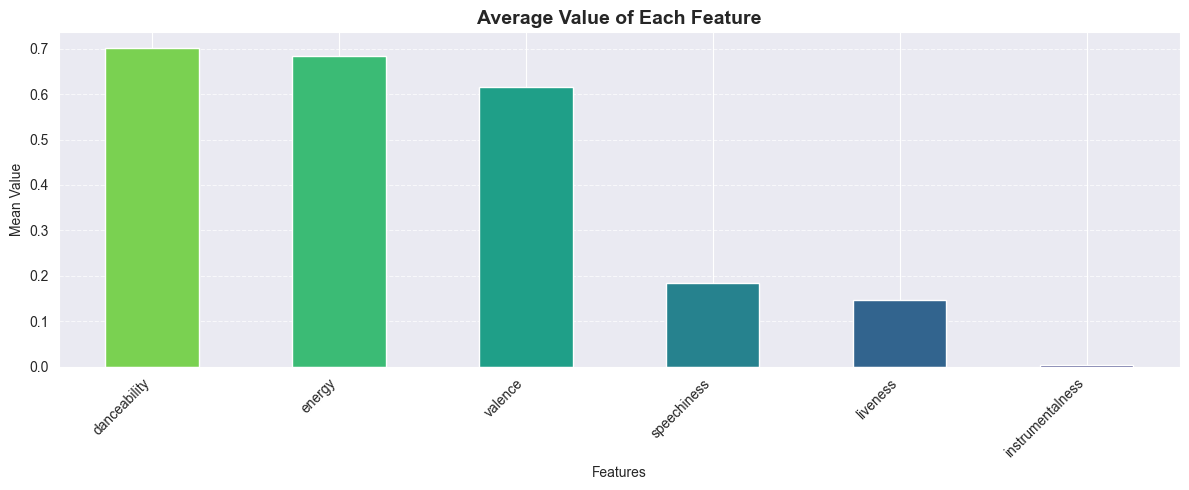

In [60]:
feature_means.plot(
    kind='bar',
    figsize=(12,5),
    color=plt.cm.viridis_r(np.linspace(0.2, 0.8, len(feature_means)))
)

plt.title('Average Value of Each Feature', fontsize=14, fontweight='bold')
plt.ylabel('Mean Value')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [61]:
# Picking the five attributes  as intrumentalness makes a minor diff
song_features = feature_means.head(5).index.tolist()
print(song_features)


['danceability', 'energy', 'valence', 'speechiness', 'liveness']


In [62]:
#using  these features create a hit score by getting the average of the normalized features
features = ['liveness', 'speechiness', 'danceability', 'energy','valence']

df['hit_score'] = df[features].mean(axis=1)

# # Define a threshold using median
# threshold = df['hit_score'].median()
# df['hit_status'] = (df['hit_score'] >= threshold).astype(int)  # 1 = banger, 0 = flop

df[['track_name', 'hit_score']].head()
df[['track_name', 'hit_score']]

,track_name,hit_score
0,Hello,0.43546
1,Properly (feat. Femi One),0.51370
2,Hapo Tu (feat. Chris Kaiga),0.47182
3,Mungu Pekee,0.49628
4,Bebi Bebi,0.42992
5,Short N Sweet,0.48700
6,Suzanna,0.49618
7,Midnight Train,0.46920
8,Insecure,0.40520
9,Sura Yako,0.52360


## MATHEMATICAL MODELLING USING LINEAR ALGEBRA


In [63]:
#USING GAUSSIAN ELIMINATION METHOD:

features = ['liveness', 'speechiness', 'danceability', 'energy', 'valence']
N = len(features) #Hence solving a 5by5 square system

# Gaussian elimination with partial pivoting
def gaussian_elimination_solve(A_in, b_in, eps=1e-12):
    # A⋅x=b ====> Augmented matric = A|b
    A = A_in.astype(float).copy()
    b = b_in.astype(float).copy().reshape(-1, 1)
    n = A.shape[0]

    # Forward elimination
    for k in range(n):
        # Partial pivoting===> picks the row with the largest value
        pivot_row = np.argmax(np.abs(A[k:n, k])) + k
        if abs(A[pivot_row, k]) < eps:
            raise ValueError("Matrix is singular or nearly singular (pivot ~ 0).")
        # Swap if a bigger pivot is found in a lower row
        if pivot_row != k:
            A[[k, pivot_row]] = A[[pivot_row, k]]
            b[[k, pivot_row]] = b[[pivot_row, k]]

        # Eliminate numbers below the pivot
        for i in range(k+1, n):
            factor = A[i, k] / A[k, k]
            A[i, k:n] = A[i, k:n] - factor * A[k, k:n]
            b[i, 0] = b[i, 0] - factor * b[k, 0]

    # Back substitution sing a trangular matrix is formed
    x = np.zeros((n, 1), dtype=float)
    for i in range(n-1, -1, -1):
        if abs(A[i, i]) < eps:
            raise ValueError("Matrix is singular or nearly singular during back substitution.")
        x[i, 0] = (b[i, 0] - np.dot(A[i, i+1:n], x[i+1:n, 0])) / A[i, i]

    return x.flatten()

# Select top-N songs by hit_score to build a square system
if df.shape[0] < N:
    raise RuntimeError(f"Not enough rows ({df.shape[0]}) to form a {N}x{N} system.")

topN = df.sort_values('hit_score', ascending=False).head(N)
A = topN[features].values
b = topN['hit_score'].values

print("Top-N track names used for the square system:")
print(topN[['track_name', 'track_id', 'hit_score']])

# Solve with Gaussian elimination function called
try:
    coeffs_gauss = gaussian_elimination_solve(A, b)
    coeffs_dict = dict(zip(features, coeffs_gauss))
    print("\nCoefficients found via Gaussian elimination (exact for these chosen rows):")
    for f, c in coeffs_dict.items():
        print(f"  {f}: {c:.6f}")

    residual = A.dot(coeffs_gauss) - b
    print("\nResiduals on the chosen top-N rows (A x - b):")
    print(residual)
    print("Max absolute residual:", np.max(np.abs(residual)))

    # Apply these coefficients
    X_all = df[features].values
    df['predicted_hit_score_gauss'] = X_all.dot(coeffs_gauss)
    top10_pred = df[['track_name', 'track_id', 'hit_score', 'predicted_hit_score_gauss']]\
                  .sort_values('predicted_hit_score_gauss', ascending=False).head(10)
    print("\nTop 10 by Gaussian solution predicted score:")
    print(top10_pred.to_string(index=False))

except ValueError as e:
    print("Gaussian elimination failed:", e)

#check condition number to see stability(sensitivity solution to data error)
cond = np.linalg.cond(A)
print(f"\nCondition number of A (top-N): {cond:.3e}")
if cond > 1e12:
    print("Warning: matrix is unstable; solution may be numerically unstable.")


Top-N track names used for the square system:
              track_name                track_id  hit_score
47  Kamati Ya Roho Chafu  4u6rWAGzucybgRpRWjEb6G    0.62800
40         Shamra Shamra  0zBeSzwKqoZ96EVfltBxp6    0.58352
49           Accelerator  4aLjA8wfNGD07wgZgrpPA2    0.55940
17                  Hepi  2HV7LKVfSS4U9oRLXOoEtv    0.55140
12          Thick Thighs  554GIS5vF1pZXRKymmYrSb    0.55140

Coefficients found via Gaussian elimination (exact for these chosen rows):
  liveness: 0.200000
  speechiness: 0.200000
  danceability: 0.200000
  energy: 0.200000
  valence: 0.200000

Residuals on the chosen top-N rows (A x - b):
[1.11022302e-16 0.00000000e+00 1.11022302e-16 1.11022302e-16
 1.11022302e-16]
Max absolute residual: 1.1102230246251565e-16

Top 10 by Gaussian solution predicted score:
                track_name               track_id  hit_score  predicted_hit_score_gauss
      Kamati Ya Roho Chafu 4u6rWAGzucybgRpRWjEb6G    0.62800                    0.62800
             Sha

# MACHINE LEARNING MODELLING

In [64]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [65]:
# Features and target
features = ['liveness', 'speechiness', 'danceability', 'energy', 'valence']
X = df[features]
y = df['hit_score']

# Split data 50/50
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)


### 1:Linear Regression

In [66]:
# Initialize and train
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test)

# Evaluate
print("Linear Regression:")
print("Coefficients:", dict(zip(features, lr_model.coef_)))
print("Intercept:", lr_model.intercept_)
print("R2 Score:", r2_score(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))


# the model is over fitting due to small data hence the model memorizes the data ===> currently spotify limits data:
# R2 Score: 1.0
# MSE: 1.266833918974715e-32

Linear Regression:
Coefficients: {'liveness': np.float64(0.19999999999999982), 'speechiness': np.float64(0.2), 'danceability': np.float64(0.20000000000000018), 'energy': np.float64(0.19999999999999998), 'valence': np.float64(0.19999999999999987)}
Intercept: 1.1102230246251565e-16
R2 Score: 1.0
MSE: 1.266833918974715e-32


In [67]:
#To shrinks coefficients we use Lasso
from sklearn.linear_model import Lasso

model = Lasso(alpha=0.001)
model.fit(X_train, y_train)
y_pred_lasso = model.predict(X_test)

from sklearn.metrics import r2_score, mean_squared_error

print("Lasso Regression:")
print("Coefficients:", dict(zip(features, model.coef_)))
print("Intercept:", model.intercept_)
print("R2 Score:", r2_score(y_test, y_pred_lasso))
print("MSE:", mean_squared_error(y_test, y_pred_lasso))



Lasso Regression:
Coefficients: {'liveness': np.float64(0.05056798907772751), 'speechiness': np.float64(0.09067882352040256), 'danceability': np.float64(0.14922259463881368), 'energy': np.float64(0.09780058787529104), 'valence': np.float64(0.1838712029590303)}
Intercept: 0.153483255517184
R2 Score: 0.8088735887897371
MSE: 0.0010450154699406156


### 2:Random Forest

In [68]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("\nRandom Forest:")
print("R2 Score:", r2_score(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))

#Since its picking randomly the model is less prone to overfitting/ memorizing the data


Random Forest:
R2 Score: 0.6332268821237077
MSE: 0.002005393078392596


In [69]:
comparison = pd.DataFrame({
    'track_name': df.loc[y_test.index, 'track_name'],
    'actual_hit_score': y_test,
    'pred_lr': y_pred_lr,
    'pred_rf': y_pred_rf,
})

print(comparison.sort_values('actual_hit_score', ascending=False).head(10))


              track_name  actual_hit_score  pred_lr   pred_rf
47  Kamati Ya Roho Chafu           0.62800  0.62800  0.516200
49           Accelerator           0.55940  0.55940  0.535119
17                  Hepi           0.55140  0.55140  0.472202
12          Thick Thighs           0.55140  0.55140  0.475641
43               Tarimbo           0.55020  0.55020  0.537514
36       Such Kinda Love           0.52830  0.52830  0.504213
30                Rewind           0.52440  0.52440  0.504241
9              Sura Yako           0.52360  0.52360  0.515224
50               KISHASH           0.51000  0.51000  0.459717
3            Mungu Pekee           0.49628  0.49628  0.505456


## Top 10 songs using linear regression

In [70]:
# Add predicted hit scores for test set
df.loc[y_test.index, 'predicted_hit_score_lr'] = y_pred_lr

#Sort and display
top_10_lr = df.loc[y_test.index, ['track_name', 'hit_score', 'predicted_hit_score_lr']]\
    .sort_values('predicted_hit_score_lr', ascending=False).head(10)

print(top_10_lr)


              track_name  hit_score  predicted_hit_score_lr
47  Kamati Ya Roho Chafu    0.62800                 0.62800
49           Accelerator    0.55940                 0.55940
17                  Hepi    0.55140                 0.55140
12          Thick Thighs    0.55140                 0.55140
43               Tarimbo    0.55020                 0.55020
36       Such Kinda Love    0.52830                 0.52830
30                Rewind    0.52440                 0.52440
9              Sura Yako    0.52360                 0.52360
50               KISHASH    0.51000                 0.51000
3            Mungu Pekee    0.49628                 0.49628


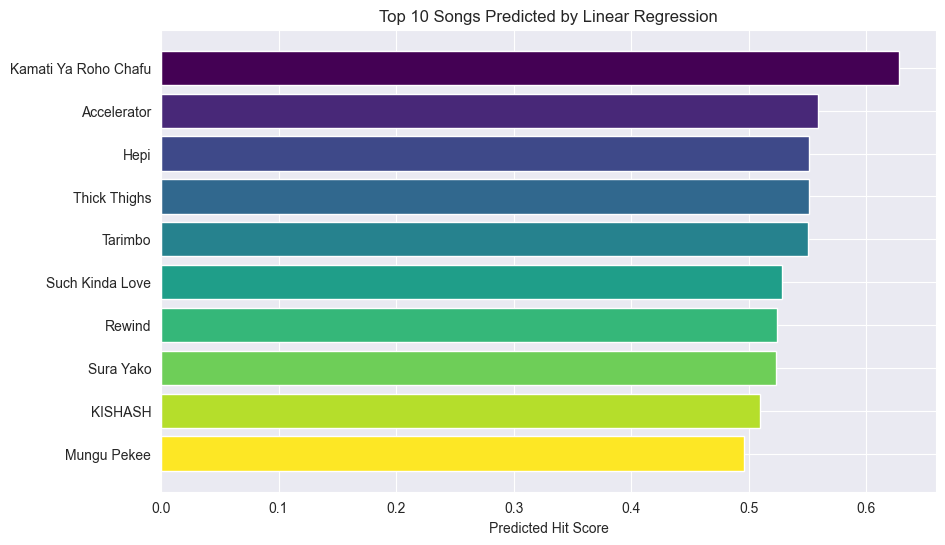

In [71]:
plt.figure(figsize=(10,6))
plt.barh(
    top_10_lr['track_name'],
    top_10_lr['predicted_hit_score_lr'],
    color=plt.cm.viridis(np.linspace(0, 1, len(top_10_lr)))
)
plt.xlabel('Predicted Hit Score')
plt.title('Top 10 Songs Predicted by Linear Regression')
plt.gca().invert_yaxis()
plt.show()


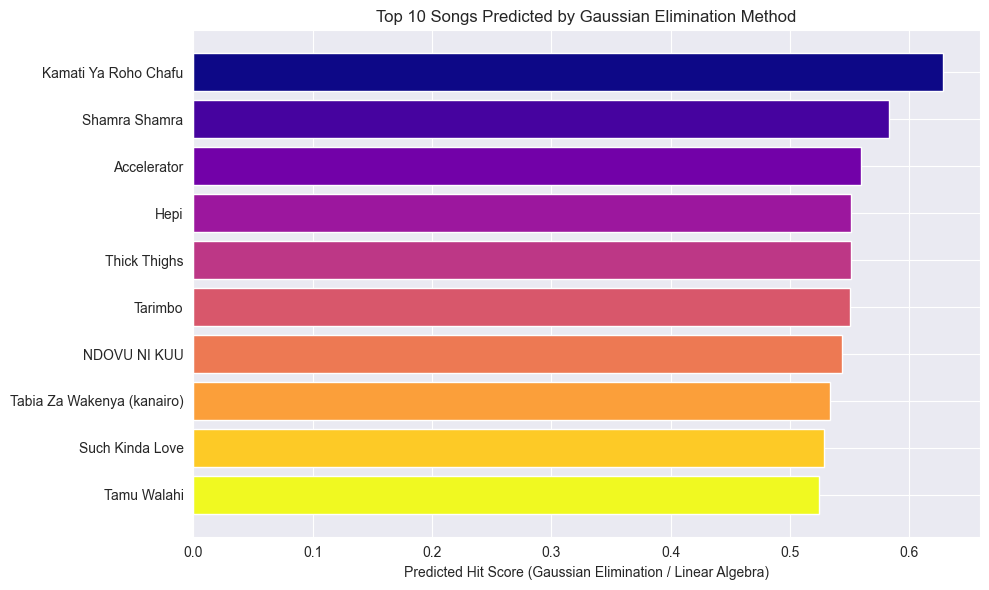

In [72]:
plt.figure(figsize=(10,6))
plt.barh(
    top10_pred['track_name'],
    top10_pred['predicted_hit_score_gauss'],
    color=plt.cm.plasma(np.linspace(0, 1, len(top10_pred)))
)
plt.xlabel('Predicted Hit Score (Gaussian Elimination / Linear Algebra)')
plt.title('Top 10 Songs Predicted by Gaussian Elimination Method')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


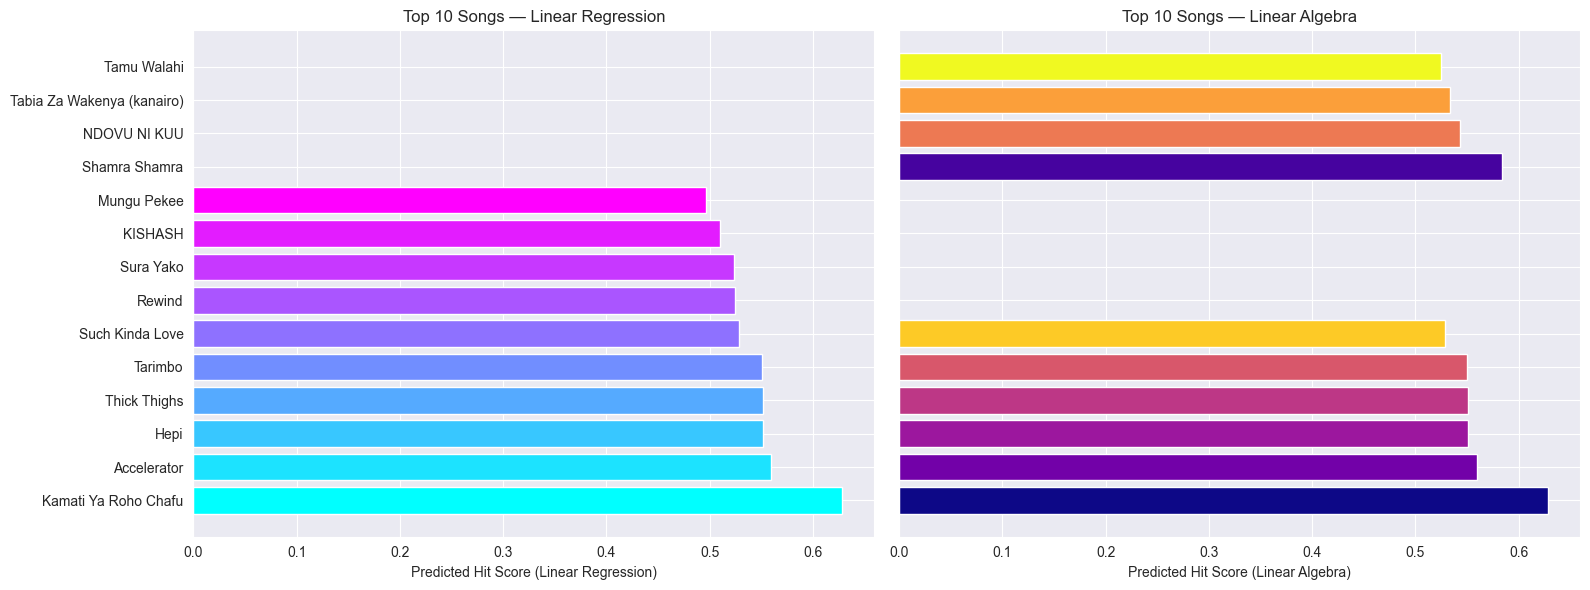

In [73]:
#Top ten Linear Regression and Linear Algebra side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

#Linear Regression
axes[0].barh(
    top_10_lr['track_name'],
    top_10_lr['predicted_hit_score_lr'],
    color=plt.cm.cool(np.linspace(0, 1, len(top_10_lr)))
)
axes[0].set_xlabel('Predicted Hit Score (Linear Regression)')
axes[0].set_title('Top 10 Songs — Linear Regression')
axes[0].invert_yaxis()

# Linear Algebra (Gaussian Elimination)
axes[1].barh(
    top10_pred['track_name'],
    top10_pred['predicted_hit_score_gauss'],
    color=plt.cm.plasma(np.linspace(0, 1, len(top10_pred)))
)
axes[1].set_xlabel('Predicted Hit Score (Linear Algebra)')
axes[1].set_title('Top 10 Songs — Linear Algebra')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


# Merge top 10 Linear Algebra and Linear Equation


In [79]:
# Merge on track_name to see differences
comparison_top10 = pd.merge(
    top_10_lr[['track_name', 'predicted_hit_score_lr']],
    top10_pred[['track_name', 'predicted_hit_score_gauss']],
    on='track_name',
    how='outer'
)

comparison_top10 = comparison_top10.fillna(0)

# difference column
comparison_top10['score_diff'] = comparison_top10['predicted_hit_score_lr'] - comparison_top10['predicted_hit_score_gauss']

# Sort by Linear Regression predicted score
comparison_top10 = comparison_top10.sort_values('predicted_hit_score_lr', ascending=False)

print(comparison_top10)


                    track_name  predicted_hit_score_lr  \
3         Kamati Ya Roho Chafu                 0.62800   
0                  Accelerator                 0.55940   
1                         Hepi                 0.55140   
13                Thick Thighs                 0.55140   
12                     Tarimbo                 0.55020   
8              Such Kinda Love                 0.52830   
6                       Rewind                 0.52440   
9                    Sura Yako                 0.52360   
2                      KISHASH                 0.51000   
4                  Mungu Pekee                 0.49628   
5                 NDOVU NI KUU                 0.00000   
7                Shamra Shamra                 0.00000   
11                 Tamu Walahi                 0.00000   
10  Tabia Za Wakenya (kanairo)                 0.00000   

    predicted_hit_score_gauss    score_diff  
3                     0.62800 -1.110223e-16  
0                     0.55940  0.0000

In [75]:
# Coefficients from Linear Regression
lr_importance = pd.Series(lr_model.coef_, index=features).sort_values(ascending=False)
print("Linear Regression Coefficients\n", lr_importance)

Linear Regression Coefficients
 danceability    0.2
speechiness     0.2
energy          0.2
valence         0.2
liveness        0.2
dtype: float64


### USING NIGERIAN TOP SONGS

In [76]:
naijaData = pd.read_csv(r'C:\Users\ChristineKakina\PycharmProjects\HitSongPredictor\Naija.csv')
features = ['liveness', 'speechiness', 'danceability', 'energy', 'valence']

# Ensure all required features exist
missing = [f for f in features if f not in naijaData.columns]
if missing:
    raise ValueError(f"Missing required features in Naija data: {missing}")

#Gaussian coefficients
naijaData['predicted_hit_score_gauss'] = naijaData[features].values.dot(coeffs_gauss)

#Linear Regression coefficients
naijaData['predicted_hit_score_lr'] = naijaData[features].values.dot(lr_importance)

top10_naija_gauss = naijaData[['track_name', 'predicted_hit_score_gauss']].sort_values('predicted_hit_score_gauss', ascending=False).head(10)
top10_naija_lr = naijaData[['track_name', 'predicted_hit_score_lr']].sort_values('predicted_hit_score_lr', ascending=False).head(10)



In [77]:
print("Top 10 predicted Naija hits (Gaussian Coefficients):")
print(top10_naija_gauss.to_string(index=False))

Top 10 predicted Naija hits (Gaussian Coefficients):
               track_name  predicted_hit_score_gauss
          Palazzo (Mixed)                    0.57800
     Essence (feat. Tems)                    0.57780
              Green Light                    0.56340
          Buga (Lo Lo Lo)                    0.56120
             Boys Are Bad                    0.55968
Oshe (feat. The Cavemen.)                    0.55640
                 Nesesari                    0.55240
         Mandeman - Remix                    0.53936
            Big Thug Boys                    0.53600
                     Gobe                    0.53420


In [78]:
print("\nTop 10 predicted Naija hits (Linear Regression Coefficients):")
print(top10_naija_lr.to_string(index=False))


Top 10 predicted Naija hits (Linear Regression Coefficients):
               track_name  predicted_hit_score_lr
          Palazzo (Mixed)                 0.57800
     Essence (feat. Tems)                 0.57780
              Green Light                 0.56340
          Buga (Lo Lo Lo)                 0.56120
             Boys Are Bad                 0.55968
Oshe (feat. The Cavemen.)                 0.55640
                 Nesesari                 0.55240
         Mandeman - Remix                 0.53936
            Big Thug Boys                 0.53600
                     Gobe                 0.53420
